In [7]:
#                                                             XOR PROBLEMİ: TEK KATMAN vs ÇOK KATMAN
# Tek katmanlı perceptron ile XOR
import numpy as np
from sklearn.linear_model import Perceptron

# XOR verisi
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,1,1,0])  # 1D array

# Tek katmanlı perceptron
tek_perceptron = Perceptron(max_iter=1000, eta0=0.1, random_state=42)
tek_perceptron.fit(X, y)

# Tahmin
tahmin_tek = tek_perceptron.predict(X)

# Sonuçları yazdır
print("XOR Girdileri:", X, sep="\n")
print("Beklenen Çıktılar:", y)
print("Tek Katmanlı Perceptron Tahminleri:", tahmin_tek)

dogruluk_tek = (tahmin_tek == y).sum() / len(y)
print(f"\nTek Katmanlı Perceptron Doğruluk: {dogruluk_tek*100:.2f}%")

XOR Girdileri:
[[0 0]
 [0 1]
 [1 0]
 [1 1]]
Beklenen Çıktılar: [0 1 1 0]
Tek Katmanlı Perceptron Tahminleri: [0 0 0 0]

Doğruluk: 50.00%


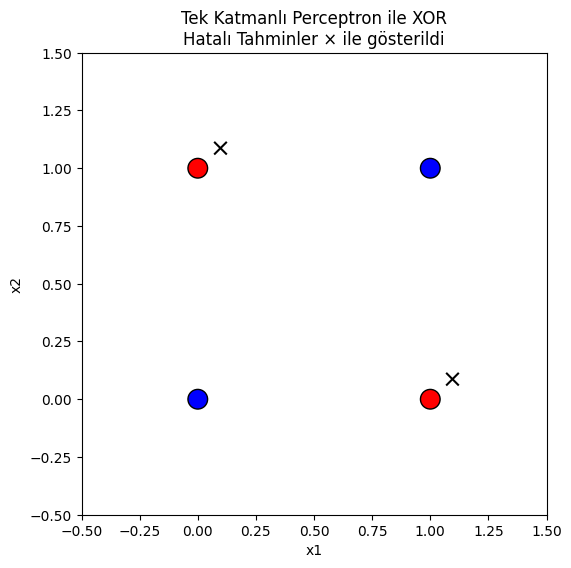

In [28]:
#tek perceptron ile

import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
colors = ['blue' if label==0 else 'red' for label in y]

# Veri noktaları
plt.scatter(X[:,0], X[:,1], c=colors, s=200, edgecolors='k')

# Hatalı tahminleri işaretle
for i in range(len(X)):
    if tahmin_tek[i] != y[i]:
        plt.text(X[i,0]+0.05, X[i,1]+0.05, '×', color='black', fontsize=18)

plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Tek Katmanlı Perceptron ile XOR\nHatalı Tahminler × ile gösterildi')
plt.show()

In [29]:
from sklearn.neural_network import MLPClassifier

# Çok katmanlı perceptron (1 gizli katman, 4 nöron, sigmoid)
mlp = MLPClassifier(hidden_layer_sizes=(4,), activation='logistic',
                    solver='lbfgs', random_state=42, max_iter=1000)
mlp.fit(X, y)

# Tahmin
tahmin_cok = mlp.predict(X)

# Sonuçları yazdır
print("Çok Katmanlı Perceptron Tahminleri:", tahmin_cok)
dogruluk_cok = (tahmin_cok == y).sum() / len(y)
print(f"\nÇok Katmanlı Perceptron Doğruluk: {dogruluk_cok*100:.2f}%")

Çok Katmanlı Perceptron Tahminleri: [0 1 1 0]

Çok Katmanlı Perceptron Doğruluk: 100.00%


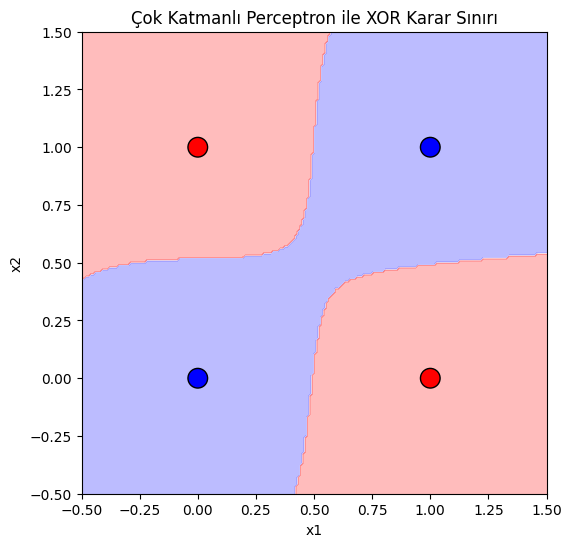

In [31]:
# Karar sınırı çizmek için grid
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200),
                     np.linspace(-0.5, 1.5, 200))
Z = mlp.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(6,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.bwr)
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.bwr, edgecolors='k', s=200)
plt.title("Çok Katmanlı Perceptron ile XOR Karar Sınırı")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()